# Simulate 1D harmonic-oscillator trajectory data

This notebook generates a clean fixed-energy trajectory for the one-dimensional harmonic oscillator and saves it as `harmonic_1d.txt`.

The output columns are

1. position `x`
2. velocity `v`

The data are compatible with the validation notebook, which assumes raw coordinates `[x, v]` and energy

$H(x,v)=\frac12 c x^2 + \frac12 m v^2.$


In [1]:
# --------------------- Imports and reproducibility ---------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

seed = 42
rng = np.random.default_rng(seed)

# Save location
output_path = Path("harmonic_1d.txt")


In [2]:
# --------------------- Oscillator and sampling parameters ---------------------
# Mechanical parameters
m = 1.0        # mass
c = 1.0        # spring constant
omega = np.sqrt(c / m)

# Fixed target energy. With m=c=1, E0=1 gives amplitude sqrt(2).
E0 = 1.0
phase0 = 0.0

# Sampling parameters
n_periods = 8
n_samples = 4000
T = 2.0 * np.pi / omega

t = np.linspace(0.0, n_periods * T, n_samples, endpoint=False)

print(f"omega = {omega:.6f}")
print(f"period T = {T:.6f}")
print(f"samples = {n_samples}")


omega = 1.000000
period T = 6.283185
samples = 4000


In [4]:
# --------------------- Analytic trajectory ---------------------
# For H = 1/2 c x^2 + 1/2 m v^2, the fixed-energy solution can be written as:
#   x(t) = sqrt(2E0/c) cos(omega t + phase0)
#   v(t) = -sqrt(2E0/m) sin(omega t + phase0)

x_amp = np.sqrt(2.0 * E0 / c)
v_amp = np.sqrt(2.0 * E0 / m)

x = x_amp * np.cos(omega * t + phase0)
v = -v_amp * np.sin(omega * t + phase0)

trajectory = np.column_stack([x, v]).astype(np.float32)

# Energy sanity check
H = 0.5 * c * trajectory[:, 0]**2 + 0.5 * m * trajectory[:, 1]**2
print(f"Energy mean: {H.mean():.8f}")
print(f"Energy std:  {H.std():.8e}")
print(f"Energy min/max: {H.min():.8f} / {H.max():.8f}")


Energy mean: 1.00000000
Energy std:  5.81565445e-08
Energy min/max: 0.99999988 / 1.00000012


In [5]:
# --------------------- Save data ---------------------
np.savetxt(
    output_path,
    trajectory,
    fmt="%.10f",
    header="x v",
    comments="# ",
)

print(f"Saved {trajectory.shape[0]} rows and {trajectory.shape[1]} columns to: {output_path.resolve()}")


Saved 4000 rows and 2 columns to: C:\Users\User\bwSyncShare2\studies\AI-in-physics_AJP_2025\code\binder_20-04-2026\github_repo_EJP_AI-in-physics_v3\UnsupervisedML_2_Detecting-conservation-laws\harmonic_1d.txt


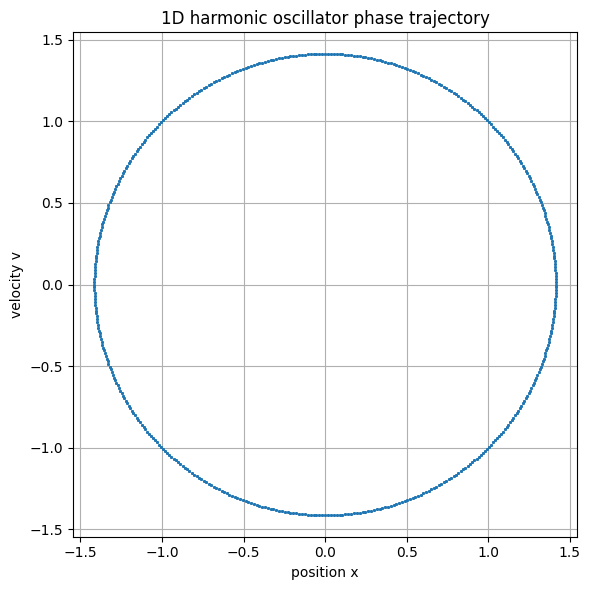

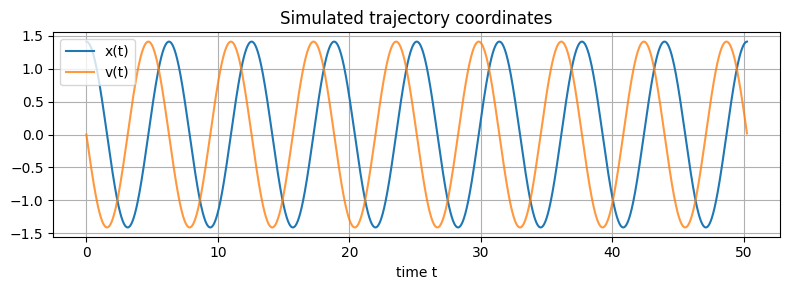

In [6]:
# --------------------- Quick visualization ---------------------
plt.figure(figsize=(6, 6))
plt.plot(trajectory[:, 0], trajectory[:, 1], ".", markersize=1.5, alpha=0.7)
plt.xlabel("position x")
plt.ylabel("velocity v")
plt.title("1D harmonic oscillator phase trajectory")
plt.axis("equal")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 3))
plt.plot(t, trajectory[:, 0], label="x(t)")
plt.plot(t, trajectory[:, 1], label="v(t)", alpha=0.8)
plt.xlabel("time t")
plt.title("Simulated trajectory coordinates")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Use with the ML notebook

Place `harmonic_1d.txt` in the same working directory as the ML notebook, or adjust

```python
model = 'harmonic_1d.txt'
```

to the full path of the generated file.
